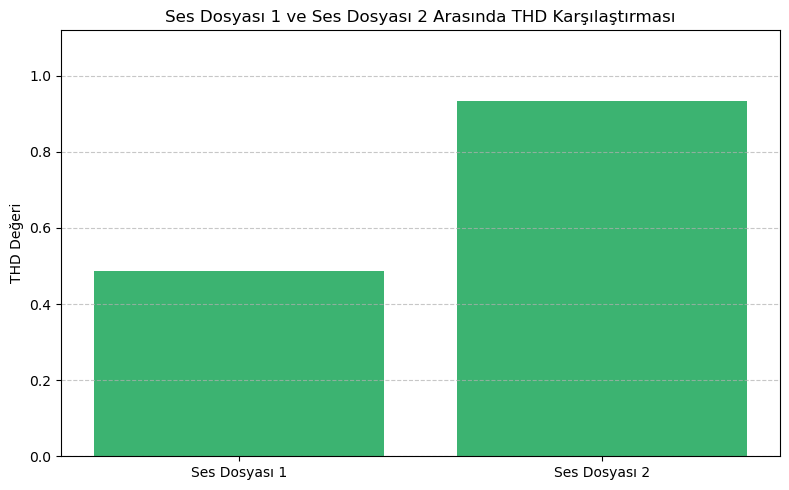

In [54]:
# Gerekli kütüphanelerin içe aktarılması
import matplotlib.pyplot as plt
import numpy as np
import librosa
import librosa.display

# İşlenecek ses dosyalarının yolları
file_1 = "/Users/nazimerensahin/Desktop/1.wav"
file_2 = "/Users/nazimerensahin/Desktop/2.wav"

# İşlenecek ses dosyalarının isimlendirmeleri
label_1 = "Ses Dosyası 1"
label_2 = "Ses Dosyası 2"

# Ses dosyalarını yükleme (dalga formu ve örnekleme hızı)
signal_1, sr_1 = librosa.load(file_1, sr=None)
signal_2, sr_2 = librosa.load(file_2, sr=None)

# THD (Total Harmonic Distortion) hesaplama - Dosya 1
# Ana frekans tespit edilir, ardından 2-5. harmoniklerin genliği bulunarak oran hesaplanır
ft1 = np.fft.fft(signal_1)
mag1 = np.abs(ft1[:len(ft1)//2])
freqs1 = np.fft.fftfreq(len(signal_1), d=1/sr_1)[:len(ft1)//2]
f_idx1 = np.argmax(mag1)
f_freq1 = freqs1[f_idx1]
harmonics1 = 0
for n in range(2, 6):
    h_freq = n * f_freq1
    h_idx = np.argmin(np.abs(freqs1 - h_freq))
    harmonics1 += mag1[h_idx]
thd1 = harmonics1 / mag1[f_idx1]

# THD (Total Harmonic Distortion) hesaplama - Dosya 2
ft2 = np.fft.fft(signal_2)
mag2 = np.abs(ft2[:len(ft2)//2])
freqs2 = np.fft.fftfreq(len(signal_2), d=1/sr_2)[:len(ft2)//2]
f_idx2 = np.argmax(mag2)
f_freq2 = freqs2[f_idx2]
harmonics2 = 0
for n in range(2, 6):
    h_freq = n * f_freq2
    h_idx = np.argmin(np.abs(freqs2 - h_freq))
    harmonics2 += mag2[h_idx]
thd2 = harmonics2 / mag2[f_idx2]

# Görsel ayarlamalar
plt.figure(figsize=(8, 5))
plt.bar([label_1, label_2], [thd1, thd2], color='mediumseagreen')
plt.ylabel("THD Değeri")
plt.title(f"{label_1} ve {label_2} Arasında THD Karşılaştırması")
plt.ylim(0, max([thd1, thd2]) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()